<div align="center" style="font-size: 2.5em; font-weight: bold; margin-bottom: 10px;">ChatGTP</div>
<div align="center" style="font-size: 1.8em; font-weight: bold; margin-bottom: 15px;">Gdje to piše (DzeToPishe)</div>
<div align="center" style="font-size: 1.3em; margin-bottom: 25px;">Diplomski rad - Automatsko ocjenjivanje odgovora</div>
<div align="right" style="font-style: italic; color: #666;">by Zlatko Pračić</div>

## 1. Postavljanje okruženja

Ovaj dio notebooka instalira potrebne biblioteke za izračun metrika i uvozi sve module.

### Instalacija potrebnih biblioteka

Instaliramo biblioteke za automatsko ocjenjivanje:
- **nltk** - BLEU metrika za n-gram preklapanje
- **rouge-score** - ROUGE-L metrika za najduži zajednički podniz
- **bert-score** - BERTScore za kontekstualnu semantičku sličnost
- **sentence-transformers** - embedding model za cosine similarity

In [1]:
!pip install nltk rouge-score bert-score
!pip install -U sentence-transformers

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 6.6 MB/s eta 0:00:00
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=37b71d0d2d5703d3baf21f8a53c10654c8bdab147a284a4fc2dfabe6b66334b8
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.3/571.3 kB 40.6 MB/s eta 0:00:00
  Attempting uninstall: sentence-transformers
    Found existing installation: sentence-transformers 5.4.0
    Uninstalling sentence-transformers-5.4.0:
      Successfully uninstalled sentence-transformers-5.4.0


### Uvoz biblioteka

Uvozimo sve potrebne module na jednom mjestu za preglednost.

In [2]:
import pandas as pd
import numpy as np
import json
import logging

import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
from bert_score import score as bert_score_fn

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity as sklearn_cosine

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

nltk.download('punkt')
nltk.download('punkt_tab')

matplotlib.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

print('Sve biblioteke uspje\u0161no u\u010ditane.')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Sve biblioteke uspješno učitane.


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


## 2. Učitavanje podataka

Učitavamo gotove rezultate iz prethodne verzije (v07) i referentne odgovore iz JSON datoteke.

### Učitavanje CSV rezultata i JSON referenci

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
csv_path = '/content/drive/My Drive/diplomskiRad/rezultati.csv'
json_path = '/content/drive/My Drive/diplomskiRad/pitanja_odgovori.json'

df = pd.read_csv(csv_path, encoding='utf-8-sig')

with open(json_path, 'r', encoding='utf-8') as f:
    qa_data = json.load(f)

# Validacija stupaca
potrebni_stupci = ['rbr', 'kategorija', 'pitanje', 'ocekivani_odgovor',
                   'vanilla_odgovor', 'rag_odgovor']
nedostaju = [s for s in potrebni_stupci if s not in df.columns]
if nedostaju:
    raise ValueError(f'Nedostaju stupci u CSV-u: {nedostaju}')

print(f'U\u010ditano {len(df)} redaka iz CSV-a.')
print(f'Stupci: {list(df.columns)}')
print(f'\nKategorije:')
print(df['kategorija'].value_counts().to_string())
print(f'\nJSON metadata: {qa_data["metadata"]["ukupno_pitanja"]} pitanja')

Učitano 31 redaka iz CSV-a.
Stupci: ['rbr', 'kategorija', 'pitanje', 'ocekivani_odgovor', 'vanilla_odgovor', 'vanilla_vrijeme_sekunde', 'rag_odgovor', 'rag_vrijeme_sekunde']

Kategorije:
kategorija
jednostavna_pitanja                   23
kompleksna_pitanja_vise_dokumenata     4
kompleksna_pitanja_jeden_dokument      4

JSON metadata: 31 pitanja


## 3. Funkcije za izračun metrika

Definiramo 4 metrike za automatsko ocjenjivanje odgovora:
- **BLEU** — leksička metrika, mjeri n-gram preklapanje (preciznost)
- **ROUGE-L** — leksička metrika, mjeri najduži zajednički podniz (F1)
- **BERTScore** — semantička metrika, kontekstualna sličnost tokena
- **Cosine Similarity** — semantička metrika, sličnost embedding vektora cijelih odgovora

In [5]:
def compute_bleu(reference, hypothesis):
    """Izra\u010dunava BLEU score izme\u0111u referentnog i generiranog odgovora.

    Koristi SmoothingFunction (method1) za kratke tekstove kako bi
    izbjegao nulu kada nema preklapanja vi\u0161ih n-grama.

    Args:
        reference: Referentni (o\u010dekivani) odgovor kao string.
        hypothesis: Generirani odgovor kao string.
    Returns:
        BLEU score kao float u rasponu [0, 1].
    """
    ref_tokens = nltk.word_tokenize(reference.lower())
    hyp_tokens = nltk.word_tokenize(hypothesis.lower())

    if len(hyp_tokens) == 0 or len(ref_tokens) == 0:
        return 0.0

    smoothie = SmoothingFunction().method1
    return sentence_bleu([ref_tokens], hyp_tokens, smoothing_function=smoothie)


def compute_rouge_l(reference, hypothesis):
    """Izra\u010dunava ROUGE-L F1 score izme\u0111u referentnog i generiranog odgovora.

    ROUGE-L mjeri najdu\u017ei zajedni\u010dki podniz (Longest Common Subsequence)
    i vra\u0107a F1 mjeru koja balansira preciznost i odziv.

    Args:
        reference: Referentni (o\u010dekivani) odgovor kao string.
        hypothesis: Generirani odgovor kao string.
    Returns:
        ROUGE-L F1 score kao float u rasponu [0, 1].
    """
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=False)
    scores = scorer.score(reference, hypothesis)
    return scores['rougeL'].fmeasure


def compute_bertscore(references, hypotheses):
    """Izra\u010dunava BERTScore za liste referenci i hipoteza (batch).

    Koristi model bert-base-multilingual-cased koji podr\u017eava hrvatski jezik.
    Vra\u0107a F1 komponentu BERTScore-a.

    Args:
        references: Lista referentnih odgovora.
        hypotheses: Lista generiranih odgovora.
    Returns:
        Lista F1 BERTScore vrijednosti kao floatovi.
    """
    P, R, F1 = bert_score_fn(
        hypotheses, references,
        model_type='bert-base-multilingual-cased',
        num_layers=9,
        verbose=True
    )
    return F1.tolist()


def compute_cosine_similarity(reference, hypothesis, model):
    """Izra\u010dunava cosine similarity izme\u0111u embeddinga referentnog i generiranog odgovora.

    Koristi multilingual-e5-large model za vektorizaciju cijelih odgovora
    i ra\u010duna kosinusnu sli\u010dnost izme\u0111u dobivenih vektora.

    Args:
        reference: Referentni odgovor kao string.
        hypothesis: Generirani odgovor kao string.
        model: SentenceTransformer model za vektorizaciju.
    Returns:
        Cosine similarity kao float u rasponu [-1, 1] (tipi\u010dno [0, 1] za tekstove).
    """
    emb_ref = model.encode([reference], convert_to_numpy=True)
    emb_hyp = model.encode([hypothesis], convert_to_numpy=True)
    return float(sklearn_cosine(emb_ref, emb_hyp)[0][0])


print('Funkcije za metrike definirane.')

Funkcije za metrike definirane.


## 4. Izračun metrika za sve odgovore

Za svaki od 31 redak računamo 4 metrike za vanilla odgovor i 4 metrike za RAG odgovor u usporedbi s očekivanim (referentnim) odgovorom.

### Inicijalizacija embedding modela

In [6]:
_transformers_logger = logging.getLogger('transformers.modeling_utils')
_prev_level = _transformers_logger.level
_transformers_logger.setLevel(logging.ERROR)

embed_model = SentenceTransformer('intfloat/multilingual-e5-large')

_transformers_logger.setLevel(_prev_level)
print('Embedding model u\u010ditan.')

modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/690 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/201 [00:00<?, ?B/s]

Embedding model učitan.


### Izračun BLEU, ROUGE-L i Cosine Similarity

In [7]:
vanilla_bleu = []
vanilla_rouge_l = []
vanilla_cosine = []
rag_bleu = []
rag_rouge_l = []
rag_cosine = []

for i, row in df.iterrows():
    ref = str(row['ocekivani_odgovor'])
    van = str(row['vanilla_odgovor'])
    rag = str(row['rag_odgovor'])

    # BLEU
    vanilla_bleu.append(compute_bleu(ref, van))
    rag_bleu.append(compute_bleu(ref, rag))

    # ROUGE-L
    vanilla_rouge_l.append(compute_rouge_l(ref, van))
    rag_rouge_l.append(compute_rouge_l(ref, rag))

    # Cosine Similarity
    vanilla_cosine.append(compute_cosine_similarity(ref, van, embed_model))
    rag_cosine.append(compute_cosine_similarity(ref, rag, embed_model))

    if (i + 1) % 10 == 0 or i == 0:
        print(f'Obra\u0111eno {i + 1}/{len(df)} pitanja...')

df['vanilla_bleu'] = vanilla_bleu
df['vanilla_rouge_l'] = vanilla_rouge_l
df['vanilla_cosine'] = vanilla_cosine
df['rag_bleu'] = rag_bleu
df['rag_rouge_l'] = rag_rouge_l
df['rag_cosine'] = rag_cosine

print(f'\nBLEU, ROUGE-L i Cosine Similarity izra\u010dunati za svih {len(df)} pitanja.')

Obrađeno 1/31 pitanja...
Obrađeno 10/31 pitanja...
Obrađeno 20/31 pitanja...
Obrađeno 30/31 pitanja...

BLEU, ROUGE-L i Cosine Similarity izračunati za svih 31 pitanja.


### Izračun BERTScore (batch)

In [8]:
references = df['ocekivani_odgovor'].astype(str).tolist()
vanilla_hypotheses = df['vanilla_odgovor'].astype(str).tolist()
rag_hypotheses = df['rag_odgovor'].astype(str).tolist()

print('Izra\u010dunavam BERTScore za vanilla odgovore...')
df['vanilla_bertscore'] = compute_bertscore(references, vanilla_hypotheses)

print('\nIzra\u010dunavam BERTScore za RAG odgovore...')
df['rag_bertscore'] = compute_bertscore(references, rag_hypotheses)

print(f'\nBERTScore izra\u010dunat za svih {len(df)} pitanja.')

Izračunavam BERTScore za vanilla odgovore...


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

calculating scores...
computing bert embedding.


  0%|          | 0/1 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/1 [00:00<?, ?it/s]

done in 0.46 seconds, 66.85 sentences/sec

BERTScore izračunat za svih 31 pitanja.


### Spremanje proširenog CSV-a

In [9]:
output_csv = '/content/drive/My Drive/diplomskiRad/rezultati_euroLLM_evaluacija_v09.csv'
df.to_csv(output_csv, index=False, encoding='utf-8-sig')

print(f'Rezultati spremljeni u: {output_csv}')
print(f'Oblik: {df.shape[0]} redaka \u00d7 {df.shape[1]} stupaca')
print(f'\nStupci: {list(df.columns)}')

# Pregled prvih redaka s metrikama
metrika_stupci = ['rbr', 'kategorija', 'vanilla_bleu', 'vanilla_rouge_l',
                  'vanilla_bertscore', 'vanilla_cosine',
                  'rag_bleu', 'rag_rouge_l', 'rag_bertscore', 'rag_cosine']
df[metrika_stupci].head()

Rezultati spremljeni u: /content/drive/My Drive/diplomskiRad/rezultati_euroLLM_evaluacija_v09.csv
Oblik: 31 redaka × 16 stupaca

Stupci: ['rbr', 'kategorija', 'pitanje', 'ocekivani_odgovor', 'vanilla_odgovor', 'vanilla_vrijeme_sekunde', 'rag_odgovor', 'rag_vrijeme_sekunde', 'vanilla_bleu', 'vanilla_rouge_l', 'vanilla_cosine', 'rag_bleu', 'rag_rouge_l', 'rag_cosine', 'vanilla_bertscore', 'rag_bertscore']


,rbr,kategorija,vanilla_bleu,vanilla_rouge_l,vanilla_bertscore,vanilla_cosine,rag_bleu,rag_rouge_l,rag_bertscore,rag_cosine
0,1,kompleksna_pitanja_vise_dokumenata,0.002670,0.092105,0.628597,0.870058,0.005456,0.070513,0.652901,0.888223
1,2,kompleksna_pitanja_vise_dokumenata,0.000000,0.000000,0.526778,0.731037,0.000000,0.000000,0.513862,0.736608
2,3,kompleksna_pitanja_vise_dokumenata,0.034074,0.118056,0.670546,0.905711,0.014281,0.160772,0.690045,0.949448
3,4,kompleksna_pitanja_vise_dokumenata,0.000000,0.000000,0.499769,0.747744,0.000000,0.000000,0.548978,0.715614
4,5,kompleksna_pitanja_jeden_dokument,0.002517,0.083019,0.627010,0.892400,0.002496,0.087649,0.610675,0.861781


## 5. Agregacija po kategorijama

Grupiramo rezultate po 3 kategorije pitanja i računamo prosječne vrijednosti svih metrika.

### Prosječne metrike po kategorijama

In [10]:
metrike = ['vanilla_bleu', 'vanilla_rouge_l', 'vanilla_bertscore', 'vanilla_cosine',
           'rag_bleu', 'rag_rouge_l', 'rag_bertscore', 'rag_cosine']

# Ljep\u0161a imena kategorija za prikaz
nazivi_kategorija = {
    'kompleksna_pitanja_vise_dokumenata': 'Kompleksna (vi\u0161e dok.)',
    'kompleksna_pitanja_jeden_dokument': 'Kompleksna (jedan dok.)',
    'jednostavna_pitanja': 'Jednostavna'
}

# Grupiranje po kategorijama - mean
df_grouped_mean = df.groupby('kategorija')[metrike].mean()
df_grouped_std = df.groupby('kategorija')[metrike].std()

# Ukupni prosjek
ukupno_mean = df[metrike].mean()
ukupno_std = df[metrike].std()

# Prikaz mean \u00b1 std po kategorijama
print('='*90)
print('PROSJE\u010cNE METRIKE PO KATEGORIJAMA (mean \u00b1 std)')
print('='*90)

for kat in df_grouped_mean.index:
    naziv = nazivi_kategorija.get(kat, kat)
    n = len(df[df['kategorija'] == kat])
    print(f'\n\u25b6 {naziv} (n={n})')
    print('-'*70)
    print(f'{"Metrika":<22} {"Vanilla":>18} {"RAG":>18}')
    print('-'*70)
    for base in ['bleu', 'rouge_l', 'bertscore', 'cosine']:
        v_m = df_grouped_mean.loc[kat, f'vanilla_{base}']
        v_s = df_grouped_std.loc[kat, f'vanilla_{base}']
        r_m = df_grouped_mean.loc[kat, f'rag_{base}']
        r_s = df_grouped_std.loc[kat, f'rag_{base}']
        label = base.upper().replace('_L', '-L').replace('BERTSCORE', 'BERTScore').replace('COSINE', 'Cosine Sim.')
        print(f'{label:<22} {v_m:>7.4f} \u00b1 {v_s:.4f}   {r_m:>7.4f} \u00b1 {r_s:.4f}')

print(f'\n{"="*90}')
print(f'\u25b6 UKUPNO (n={len(df)})')
print('-'*70)
print(f'{"Metrika":<22} {"Vanilla":>18} {"RAG":>18}')
print('-'*70)
for base in ['bleu', 'rouge_l', 'bertscore', 'cosine']:
    v_m = ukupno_mean[f'vanilla_{base}']
    v_s = ukupno_std[f'vanilla_{base}']
    r_m = ukupno_mean[f'rag_{base}']
    r_s = ukupno_std[f'rag_{base}']
    label = base.upper().replace('_L', '-L').replace('BERTSCORE', 'BERTScore').replace('COSINE', 'Cosine Sim.')
    print(f'{label:<22} {v_m:>7.4f} \u00b1 {v_s:.4f}   {r_m:>7.4f} \u00b1 {r_s:.4f}')
print('='*90)

PROSJEČNE METRIKE PO KATEGORIJAMA (mean ± std)

▶ Jednostavna (n=23)
----------------------------------------------------------------------
Metrika                           Vanilla                RAG
----------------------------------------------------------------------
BLEU                    0.0234 ± 0.0229    0.0844 ± 0.1416
ROUGE-L                 0.1205 ± 0.0605    0.2184 ± 0.2084
BERTScore               0.6782 ± 0.0275    0.7122 ± 0.0720
Cosine Sim.             0.9025 ± 0.0229    0.9203 ± 0.0306

▶ Kompleksna (jedan dok.) (n=4)
----------------------------------------------------------------------
Metrika                           Vanilla                RAG
----------------------------------------------------------------------
BLEU                    0.0040 ± 0.0017    0.0211 ± 0.0213
ROUGE-L                 0.0827 ± 0.0125    0.1284 ± 0.0570
BERTScore               0.6319 ± 0.0118    0.6683 ± 0.0488
Cosine Sim.             0.8621 ± 0.0371    0.8914 ± 0.0255

▶ Kompleksna (više 

### Tablica usporedbe - Vanilla vs. RAG (ukupno)

In [11]:
summary_data = []
for base in ['bleu', 'rouge_l', 'bertscore', 'cosine']:
    label = base.upper().replace('_L', '-L').replace('BERTSCORE', 'BERTScore').replace('COSINE', 'Cosine Sim.')
    v_mean = df[f'vanilla_{base}'].mean()
    r_mean = df[f'rag_{base}'].mean()
    diff = r_mean - v_mean
    summary_data.append({
        'Metrika': label,
        'Vanilla (prosjek)': round(v_mean, 4),
        'RAG (prosjek)': round(r_mean, 4),
        'Razlika (RAG - Vanilla)': round(diff, 4),
        'Pobolj\u0161anje (%)': round(diff / max(v_mean, 1e-9) * 100, 1)
    })

df_summary = pd.DataFrame(summary_data)
df_summary

,Metrika,Vanilla (prosjek),RAG (prosjek),Razlika (RAG - Vanilla),Poboljšanje (%)
0,BLEU,0.0190,0.0660,0.0469,246.4
1,ROUGE-L,0.1069,0.1861,0.0792,74.2
2,BERTScore,0.6598,0.6922,0.0325,4.9
3,Cosine Sim.,0.8858,0.9040,0.0182,2.1


## 6. Vizualizacija

Grafički prikaz rezultata za diplomski rad.

### Bar chart: Vanilla vs. RAG po metrici (ukupni prosjek)

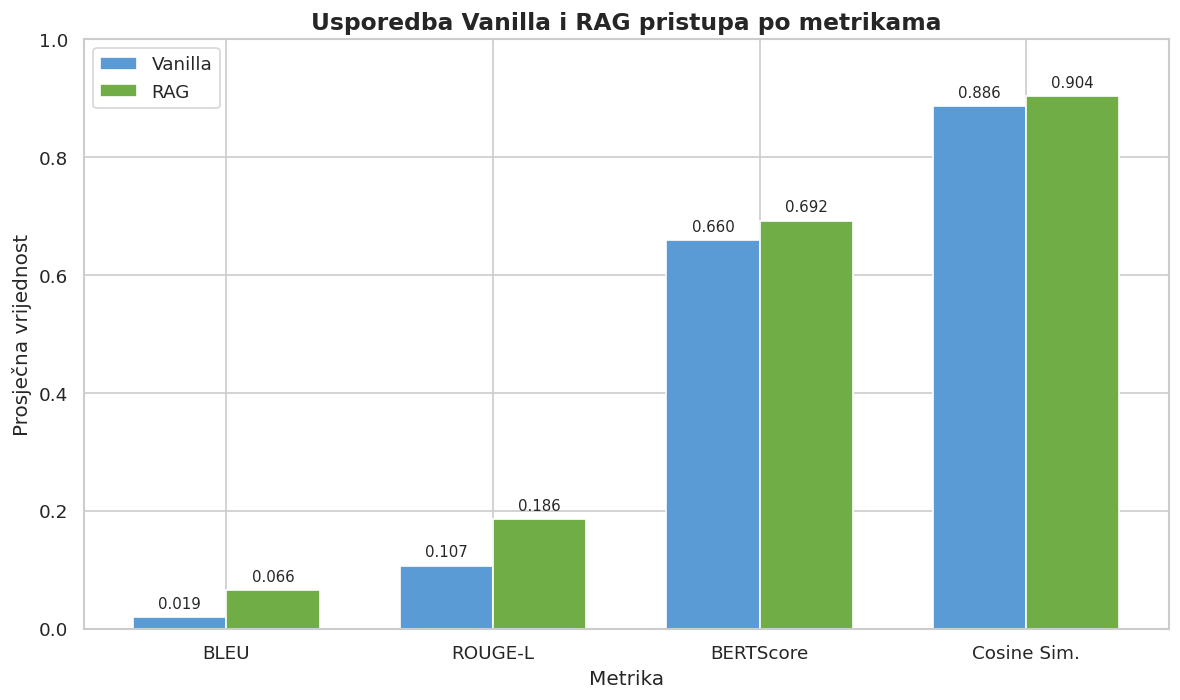

Graf spremljen: graf_vanilla_vs_rag.png


In [12]:
metrika_nazivi = ['BLEU', 'ROUGE-L', 'BERTScore', 'Cosine Sim.']
metrika_baze = ['bleu', 'rouge_l', 'bertscore', 'cosine']

vanilla_means = [df[f'vanilla_{b}'].mean() for b in metrika_baze]
rag_means = [df[f'rag_{b}'].mean() for b in metrika_baze]

x = np.arange(len(metrika_nazivi))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, vanilla_means, width, label='Vanilla', color='#5B9BD5', edgecolor='white')
bars2 = ax.bar(x + width/2, rag_means, width, label='RAG', color='#70AD47', edgecolor='white')

ax.set_xlabel('Metrika', fontsize=12)
ax.set_ylabel('Prosje\u010dna vrijednost', fontsize=12)
ax.set_title('Usporedba Vanilla i RAG pristupa po metrikama', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrika_nazivi, fontsize=11)
ax.set_ylim(0, 1.0)
ax.legend(fontsize=11)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('graf_vanilla_vs_rag.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graf spremljen: graf_vanilla_vs_rag.png')

### Grouped bar chart: Metrike po kategorijama

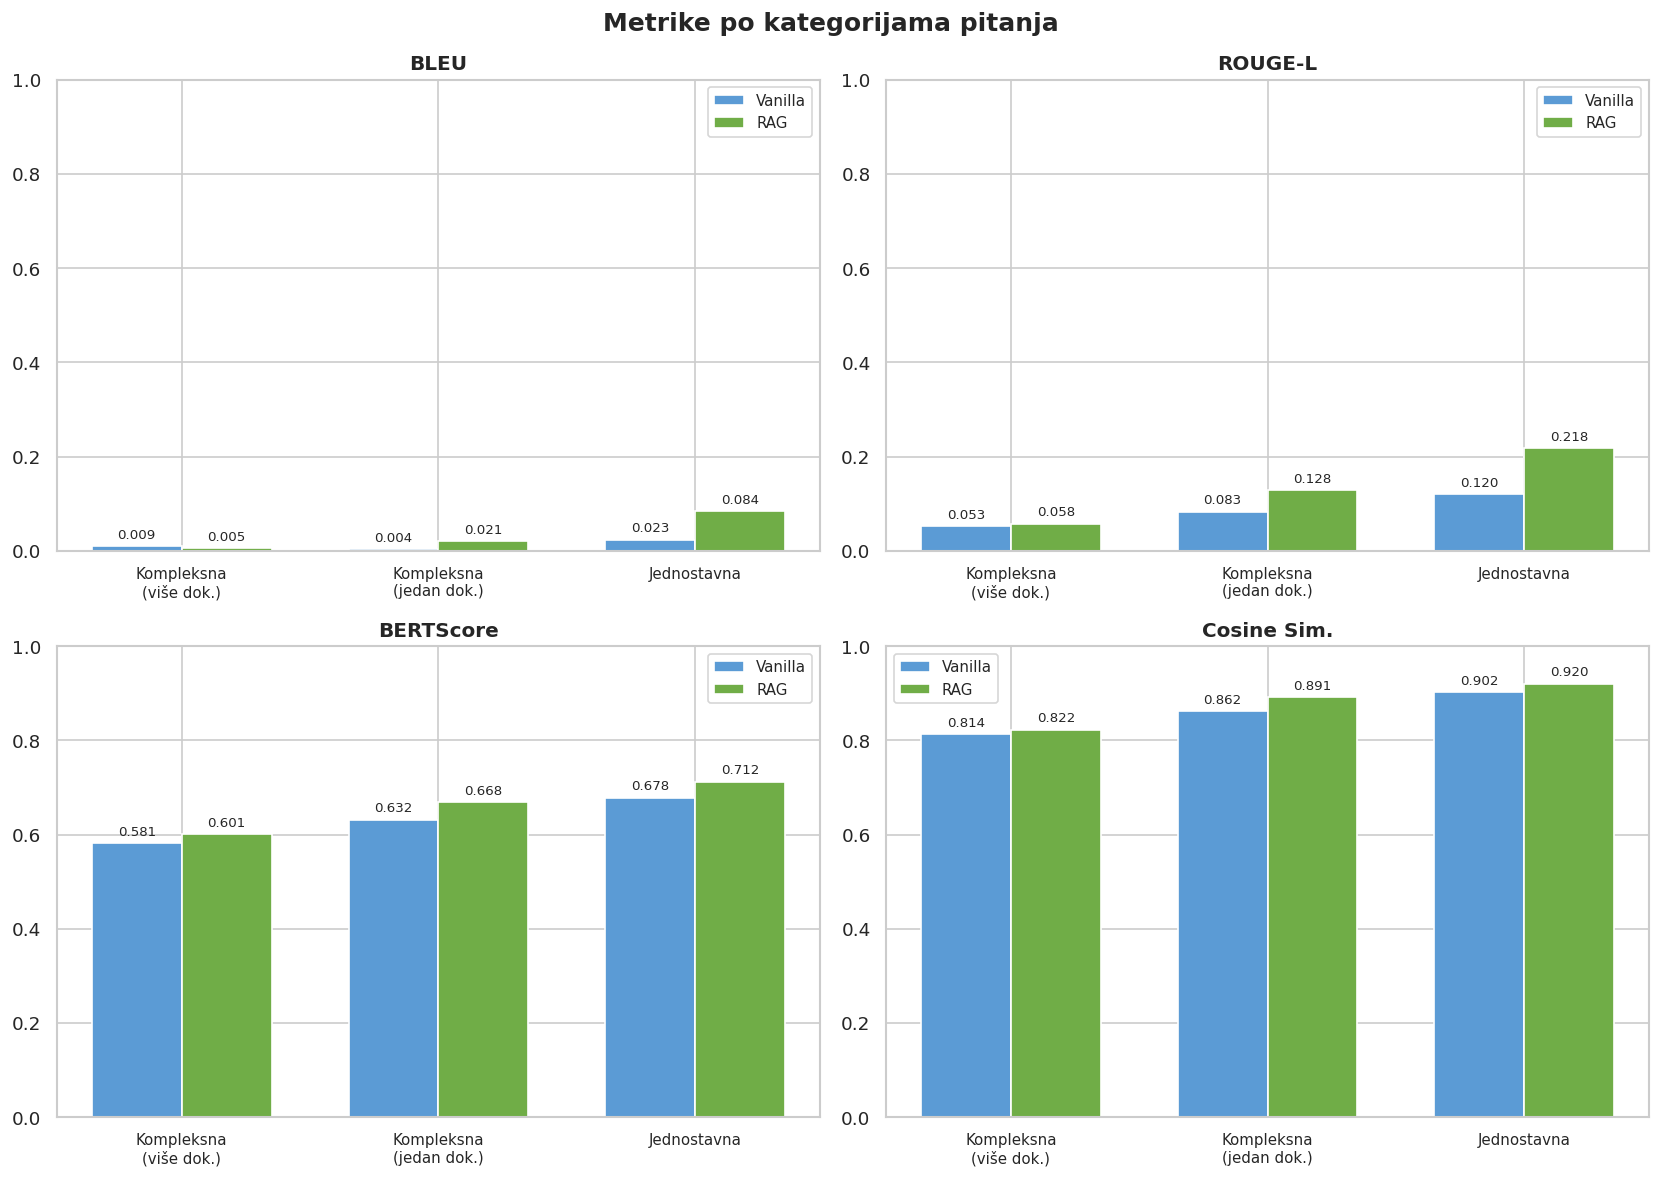

Graf spremljen: graf_metrike_po_kategorijama.png


In [13]:
kategorije_redoslijed = [
    'kompleksna_pitanja_vise_dokumenata',
    'kompleksna_pitanja_jeden_dokument',
    'jednostavna_pitanja'
]
kategorije_kratko = ['Kompleksna\n(vi\u0161e dok.)', 'Kompleksna\n(jedan dok.)', 'Jednostavna']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Metrike po kategorijama pitanja', fontsize=15, fontweight='bold')

for idx, (base, naziv) in enumerate(zip(metrika_baze, metrika_nazivi)):
    ax = axes[idx // 2][idx % 2]
    x = np.arange(len(kategorije_redoslijed))
    width = 0.35

    v_vals = [df[df['kategorija'] == k][f'vanilla_{base}'].mean() for k in kategorije_redoslijed]
    r_vals = [df[df['kategorija'] == k][f'rag_{base}'].mean() for k in kategorije_redoslijed]

    ax.bar(x - width/2, v_vals, width, label='Vanilla', color='#5B9BD5', edgecolor='white')
    ax.bar(x + width/2, r_vals, width, label='RAG', color='#70AD47', edgecolor='white')

    ax.set_title(naziv, fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(kategorije_kratko, fontsize=9)
    ax.set_ylim(0, 1.0)
    ax.legend(fontsize=9)

    for j, (v, r) in enumerate(zip(v_vals, r_vals)):
        ax.text(j - width/2, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=8)
        ax.text(j + width/2, r + 0.01, f'{r:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('graf_metrike_po_kategorijama.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graf spremljen: graf_metrike_po_kategorijama.png')

### Heatmap: Matrica svih metrika po pitanjima

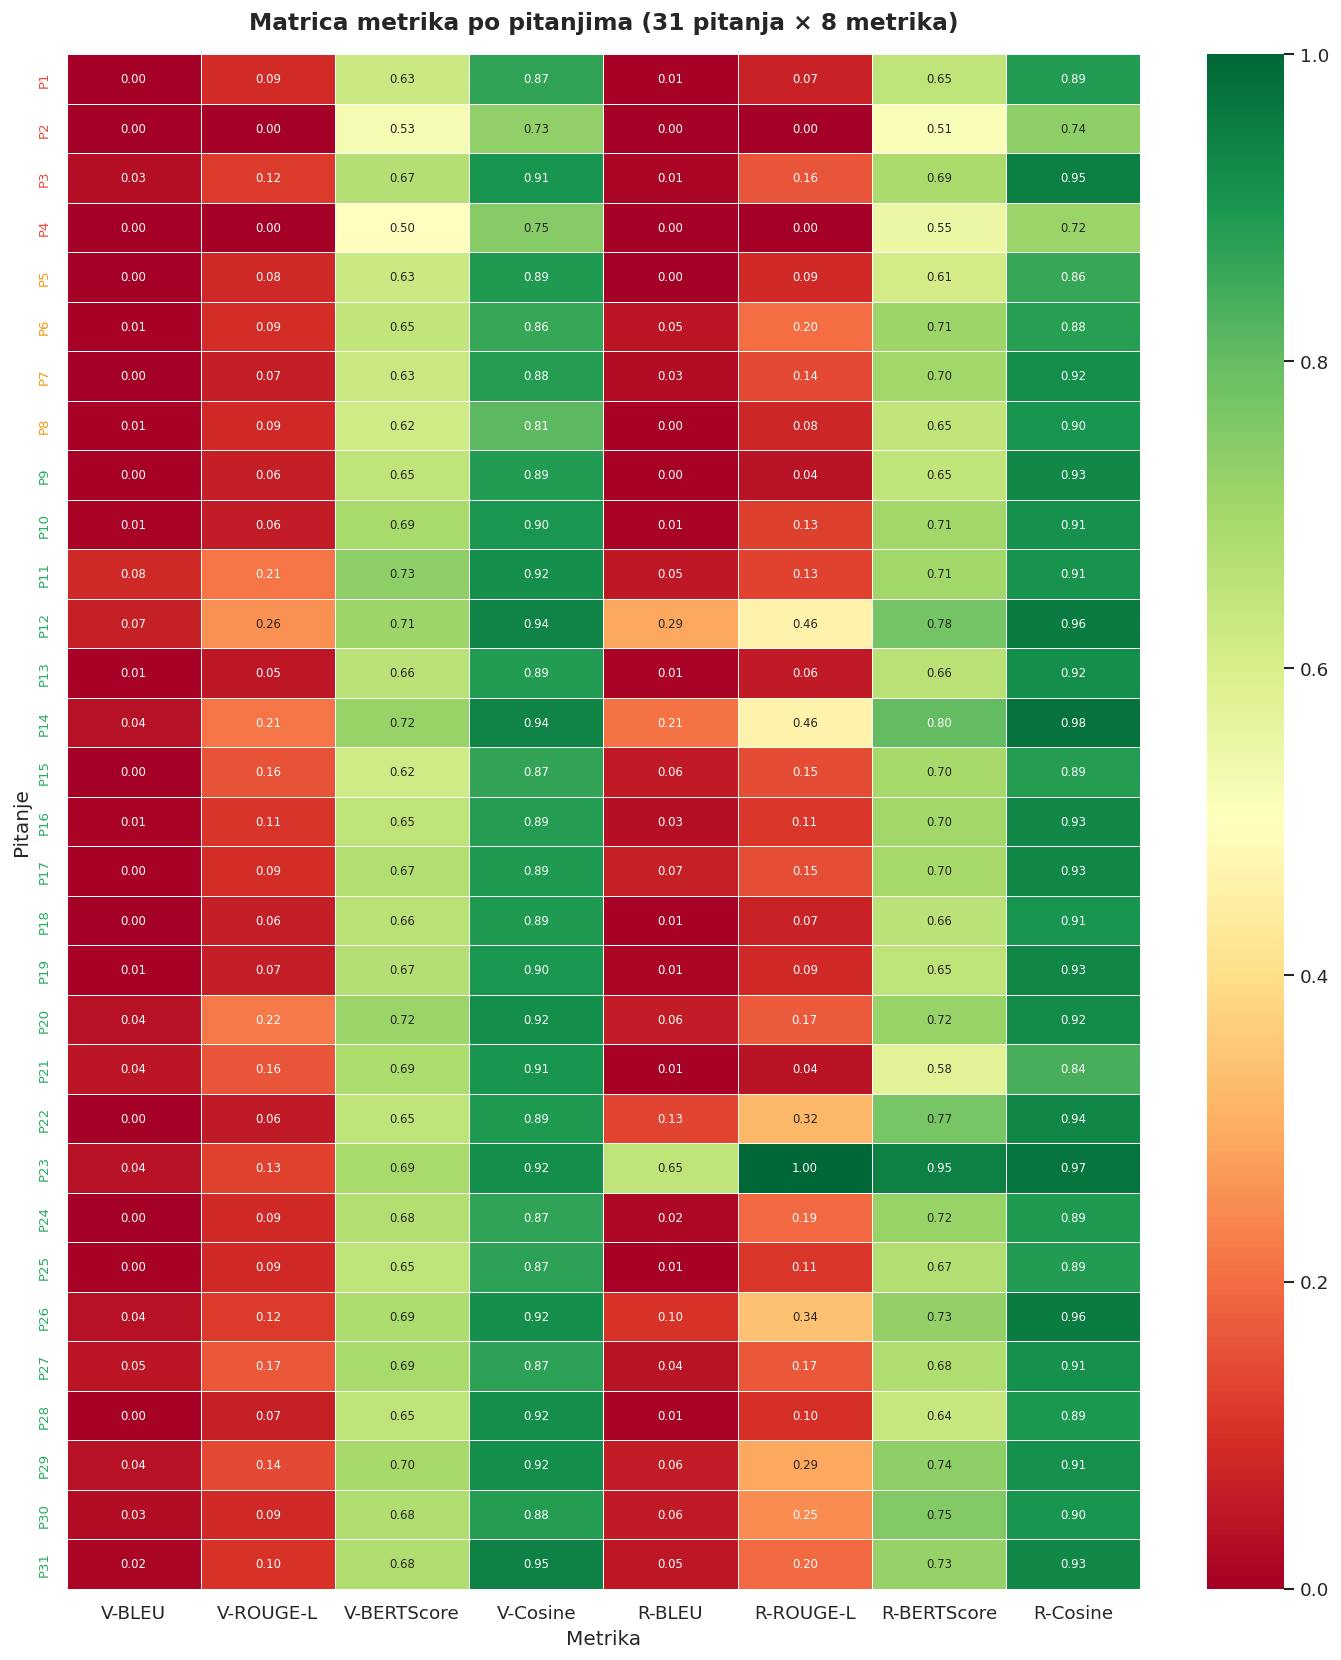

Graf spremljen: graf_heatmap_metrike.png

Legenda boja (Y os):
  Crvena = Kompleksna (više dokumenata)
  Narančasta = Kompleksna (jedan dokument)
  Zelena = Jednostavna pitanja


In [14]:
heatmap_stupci = ['vanilla_bleu', 'vanilla_rouge_l', 'vanilla_bertscore', 'vanilla_cosine',
                  'rag_bleu', 'rag_rouge_l', 'rag_bertscore', 'rag_cosine']
heatmap_nazivi = ['V-BLEU', 'V-ROUGE-L', 'V-BERTScore', 'V-Cosine',
                  'R-BLEU', 'R-ROUGE-L', 'R-BERTScore', 'R-Cosine']

heatmap_data = df[heatmap_stupci].copy()
heatmap_data.columns = heatmap_nazivi
heatmap_data.index = [f'P{i+1}' for i in range(len(df))]

fig, ax = plt.subplots(figsize=(12, 14))
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=0, vmax=1, linewidths=0.5, ax=ax,
            annot_kws={'size': 7})

ax.set_title('Matrica metrika po pitanjima (31 pitanja \u00d7 8 metrika)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Pitanje', fontsize=12)
ax.set_xlabel('Metrika', fontsize=12)

# Oznake kategorija na Y osi
y_colors = []
for kat in df['kategorija']:
    if 'vise' in kat:
        y_colors.append('#E74C3C')
    elif 'jeden' in kat:
        y_colors.append('#F39C12')
    else:
        y_colors.append('#27AE60')
for tick_label, color in zip(ax.get_yticklabels(), y_colors):
    tick_label.set_color(color)
    tick_label.set_fontsize(8)

plt.tight_layout()
plt.savefig('graf_heatmap_metrike.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graf spremljen: graf_heatmap_metrike.png')
print('\nLegenda boja (Y os):')
print('  Crvena = Kompleksna (vi\u0161e dokumenata)')
print('  Naran\u010dasta = Kompleksna (jedan dokument)')
print('  Zelena = Jednostavna pitanja')

## 7. Zaključak

Sažetak rezultata automatskog ocjenjivanja.

In [15]:
print('='*70)
print('SA\u017dETAK AUTOMATSKOG OCJENJIVANJA')
print('='*70)
print(f'Broj pitanja: {len(df)}')
print(f'Broj metrika: 4 (BLEU, ROUGE-L, BERTScore, Cosine Similarity)')
print(f'Broj kategorija: 3')
print()

print('Ukupni prosjeci:')
print(f'{"":<22} {"Vanilla":>10} {"RAG":>10} {"Razlika":>10}')
print('-'*55)
for base in ['bleu', 'rouge_l', 'bertscore', 'cosine']:
    label = base.upper().replace('_L', '-L').replace('BERTSCORE', 'BERTScore').replace('COSINE', 'Cosine Sim.')
    v = df[f'vanilla_{base}'].mean()
    r = df[f'rag_{base}'].mean()
    d = r - v
    znak = '+' if d >= 0 else ''
    print(f'{label:<22} {v:>10.4f} {r:>10.4f} {znak}{d:>9.4f}')

print()
rag_bolji = 0
for base in metrika_baze:
    if df[f'rag_{base}'].mean() > df[f'vanilla_{base}'].mean():
        rag_bolji += 1
print(f'RAG je bolji u {rag_bolji}/4 metrika.')
print('='*70)

SAŽETAK AUTOMATSKOG OCJENJIVANJA
Broj pitanja: 31
Broj metrika: 4 (BLEU, ROUGE-L, BERTScore, Cosine Similarity)
Broj kategorija: 3

Ukupni prosjeci:
                          Vanilla        RAG    Razlika
-------------------------------------------------------
BLEU                       0.0190     0.0660 +   0.0469
ROUGE-L                    0.1069     0.1861 +   0.0792
BERTScore                  0.6598     0.6922 +   0.0325
Cosine Sim.                0.8858     0.9040 +   0.0182

RAG je bolji u 4/4 metrika.
